In [1]:
!pip install -q ultralytics roboflow opencv-python matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Home\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# --- CONFIG ---
MODEL_PATH = "best.pt"
IMAGE_PATH = "a1.png"

# --- LOAD MODEL ---
model = YOLO(MODEL_PATH)


image 1/1 c:\Users\Home\Desktop\RADIX\MicroServico-HACKTON-Radix\Notebooks\a1.png: 576x1024 5 0s, 504.8ms
Speed: 48.9ms preprocess, 504.8ms inference, 40.7ms postprocess per image at shape (1, 3, 576, 1024)
✅ 5 placas solares detectadas


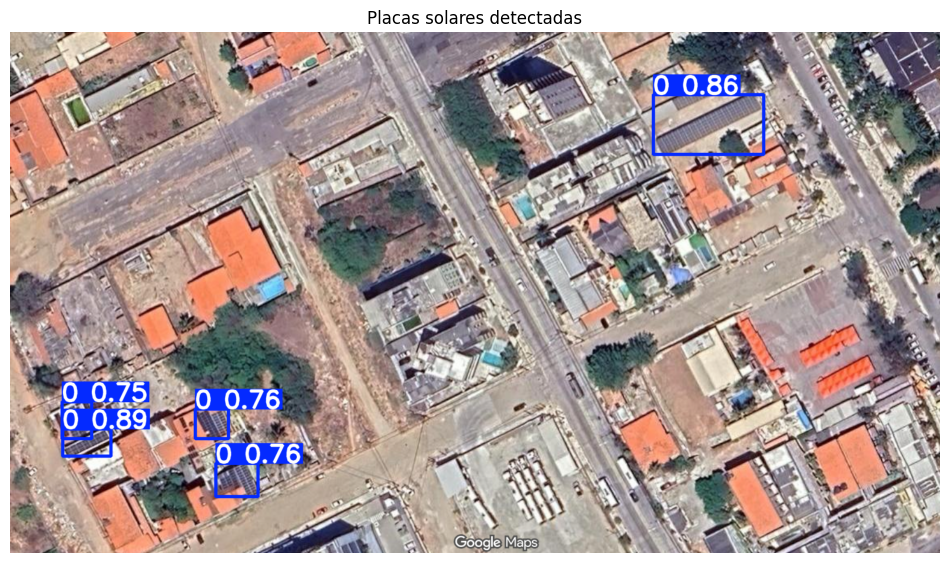

True

In [4]:

# --- INFERENCE ---
results = model.predict(
    source=IMAGE_PATH,
    imgsz=1024,
    conf=0.7,
    iou=0.2
)

# --- CHECK RESULT ---
if len(results[0].boxes) == 0:
    print("⚠️ Nenhuma placa solar detectada")
else:
    print(f"✅ {len(results[0].boxes)} placas solares detectadas")

# --- PLOT RESULT ---
img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Placas solares detectadas")
plt.show()

# --- SAVE OUTPUT (opcional) ---
cv2.imwrite("resultado_detectado.png", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
